# Q7 Problem 1a: Predicting Von Mises Stress using CNN



## Step 0: Imports


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


---
## Step 1: Load Data


In [2]:
ddir   = './dataset'
xfl  = os.path.join(ddir, 'output.xlsx')
sdir = os.path.join(ddir, 'stress')
cfil  = os.path.join(ddir, 'cord.txt')

def nsort(path):
    numbers = re.findall(r'\d+', os.path.basename(path))
    return int(numbers[0]) if numbers else 0

print('Loading output.xlsx ...')
dft = pd.read_excel(xfl, header=None)
xraw = dft.values.astype(np.float32)
print(f'   Shape: {xraw.shape}')

print('\nLoading stress files ...')
sfls = sorted(glob.glob(os.path.join(sdir, '*.txt')),
                      key=nsort)
print(f'   Found   : {len(sfls)} files')
print(f'   First   : {os.path.basename(sfls[0])}')
print(f'   Last    : {os.path.basename(sfls[-1])}')

assert len(sfls) == len(xraw), \
    f'Mismatch! Excel={len(xraw)} rows, Stress files={len(sfls)}'

msl = []
for f in tqdm(sfls, desc='Reading stress files'):
    try:
        data = np.loadtxt(f)
        msl.append(data[:, 0].max())
    except Exception as e:
        print(f'Error reading {f}: {e}')
        msl.append(np.nan)

yraw = np.array(msl, dtype=np.float32)
print(f'\nStress array shape : {yraw.shape}')
print(f'   Min  : {yraw.min():.2f}')
print(f'   Max  : {yraw.max():.2f}')
print(f'   Mean : {yraw.mean():.2f}')
print(f'   Std  : {yraw.std():.2f}')


Loading output.xlsx ...
   Shape: (5000, 226)

Loading stress files ...
   Found   : 5000 files
   First   : stress_0.txt
   Last    : stress_4999.txt


Reading stress files:  12%|█▏        | 582/5000 [00:21<02:43, 27.07it/s]


KeyboardInterrupt: 

In [ ]:
print('PAIRING SANITY CHECK')
for i in [0, 1, 2, 4999]:
    fname = os.path.basename(sfls[i])
    stressVal = yraw[i]
    thicknessSample = xraw[i, :3]
    print(f'  Row {i:4d} | File: {fname:15s} | Max Stress: {stressVal:.2f} | Thickness[:3]: {thicknessSample}')

vmask = ~np.isnan(yraw)
xraw = xraw[vmask]
yraw = yraw[vmask]
print(f'\nAfter NaN removal: X={xraw.shape}, y={yraw.shape}')


=== PAIRING SANITY CHECK ===
  Row    0 | File: stress_0.txt    | Max Stress: 9380993.00 | Thickness[:3]: [0.00085805 0.00074065 0.00140514]
  Row    1 | File: stress_1.txt    | Max Stress: 7476191.00 | Thickness[:3]: [0.00102328 0.00126736 0.00090836]
  Row    2 | File: stress_2.txt    | Max Stress: 6419735.00 | Thickness[:3]: [0.00144436 0.00095743 0.00091877]
  Row 4999 | File: stress_4999.txt | Max Stress: 6550185.00 | Thickness[:3]: [0.00118311 0.00171758 0.00090329]

After NaN removal: X=(5000, 226), y=(5000,)


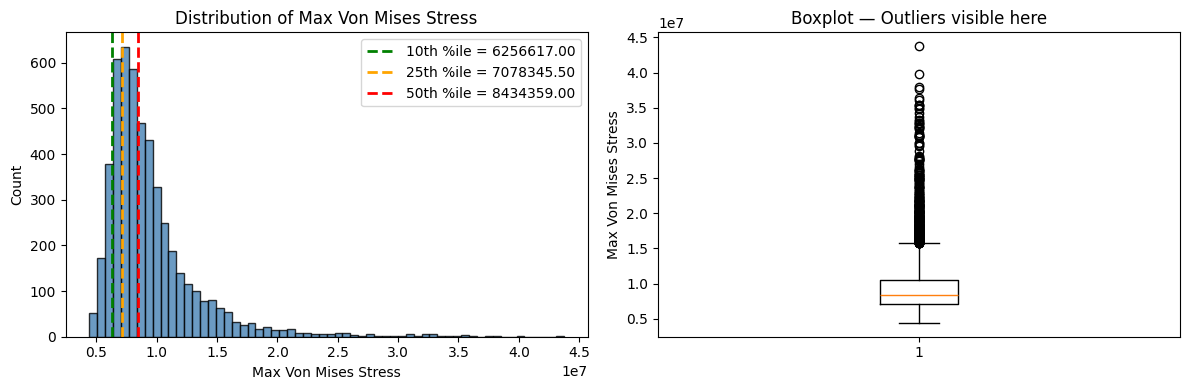

Percentile thresholds:
  10th: 6256617.00
  25th: 7078345.50
  50th: 8434359.00


In [ ]:
p10 = np.percentile(yraw, 10)
p25 = np.percentile(yraw, 25)
p50 = np.percentile(yraw, 50)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(yraw, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(p10, color='green',  linestyle='--', linewidth=2, label=f'10th %ile = {p10:.2f}')
plt.axvline(p25, color='orange', linestyle='--', linewidth=2, label=f'25th %ile = {p25:.2f}')
plt.axvline(p50, color='red',    linestyle='--', linewidth=2, label=f'50th %ile = {p50:.2f}')
plt.xlabel('Max Von Mises Stress')
plt.ylabel('Count')
plt.title('Distribution of Max Von Mises Stress')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(yraw, vert=True)
plt.ylabel('Max Von Mises Stress')
plt.title('Boxplot — Outliers visible here')

plt.tight_layout()
plt.show()

print(f'Percentile thresholds:')
print(f'  10th: {p10:.2f}')
print(f'  25th: {p25:.2f}')
print(f'  50th: {p50:.2f}')


---
## Step 2: Preprocessing


In [ ]:
sclr = StandardScaler()
xscl = sclr.fit_transform(xraw).astype(np.float32)

print(f'X scaled — mean: {xscl.mean():.4f}, std: {xscl.std():.4f}')

ylog = np.log1p(yraw).astype(np.float32)

ymean = ylog.mean()
ystd  = ylog.std()
yreg = ((ylog - ymean) / ystd).astype(np.float32)

print(f'ylog  — mean: {ylog.mean():.4f}, std: {ylog.std():.4f}')
print(f'y_norm — mean: {yreg.mean():.4f}, std: {yreg.std():.4f}')
print(f'ymean={ymean:.4f}, ystd={ystd:.4f}  ← save these for de-normalization')


X scaled — mean: 0.0000, std: 1.0000
y_log  — mean: 16.0044, std: 0.3312
y_norm — mean: -0.0000, std: 1.0000
y_mean=16.0044, y_std=0.3312  ← save these for de-normalization


Class distribution:
  Class 0 (0-10%): 500 samples (10.0%)
  Class 1 (11-25%): 750 samples (15.0%)
  Class 2 (26-50%): 1250 samples (25.0%)
  Class 3 (51-100%): 2500 samples (50.0%)


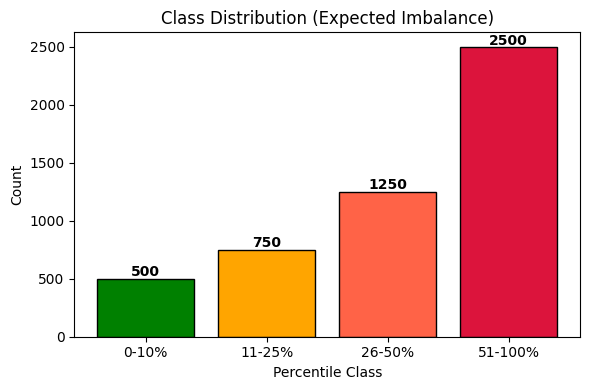

In [ ]:
def asg(stressVal, p10, p25, p50):
    if   stressVal <= p10: return 0
    elif stressVal <= p25: return 1
    elif stressVal <= p50: return 2
    else:                   return 3

ycls = np.array([asg(s, p10, p25, p50) for s in yraw], dtype=np.int64)

print('Class distribution:')
cnm = ['0-10%', '11-25%', '26-50%', '51-100%']
uniq, cnt = np.uniq(ycls, return_counts=True)
for u, c in zip(uniq, cnt):
    print(f'  Class {u} ({cnm[u]}): {c} samples ({100*c/len(ycls):.1f}%)')

plt.figure(figsize=(6, 4))
plt.bar(cnm, cnt, color=['green','orange','tomato','crimson'], edgecolor='black')
plt.xlabel('Percentile Class')
plt.ylabel('Count')
plt.title('Class Distribution (Expected Imbalance)')
for i, c in enumerate(cnt):
    plt.text(i, c + 20, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 3: Dataset & DataLoaders


In [ ]:
class BData(Dataset):
    """
    Custom Dataset.
    Input  shape: (N, 1, 226)  ← 1D CNN expects (batch, channels, length)
    Target shape: (N, 1) for regression | (N,) for classification
    """
    def __init__(self, X, y, task='regression'):
        self.X    = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.task = task
        if task == 'regression':
            self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        else:
            self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def mkdlr(X, y, task, valRatio=0.15, testRatio=0.15, batchSize=64):
    dataset = BData(X, y, task=task)
    N       = len(dataset)
    nTest  = int(N * testRatio)
    nVal   = int(N * valRatio)
    nTrain = N - nVal - nTest

    trainDs, valDs, testDs = random_split(
        dataset, [nTrain, nVal, nTest],
        generator=torch.Generator().manual_seed(42)
    )
    trainLoader = DataLoader(trainDs, batchSize=batchSize, shuffle=True,  num_workers=0)
    valLoader   = DataLoader(valDs,   batchSize=batchSize, shuffle=False, num_workers=0)
    testLoader  = DataLoader(testDs,  batchSize=batchSize, shuffle=False, num_workers=0)

    print(f'[{task}] Train={nTrain} | Val={nVal} | Test={nTest}')
    return trainLoader, valLoader, testLoader


trr, valr, ter = mkdlr(xscl, yreg, task='regression')
trainCls, valCls, testCls = mkdlr(xscl, ycls,      task='classification')


[regression] Train=3500 | Val=750 | Test=750
[classification] Train=3500 | Val=750 | Test=750


In [ ]:
cord = np.loadtxt(cfil)
print(f"cord.txt shape: {cord.shape}")
print(f"X range: {cord[:,0].min():.3f} → {cord[:,0].max():.3f}")
print(f"Y range: {cord[:,1].min():.3f} → {cord[:,1].max():.3f}")

uniqueX = np.uniq(np.round(cord[:,0], 4))
uniqueY = np.uniq(np.round(cord[:,1], 4))
print(f"\nUnique X positions: {len(uniqueX)}")
print(f"Unique Y positions: {len(uniqueY)}")
print(f"Product: {len(uniqueX) * len(uniqueY)}")
print(f"\nThickness nodes (output.xlsx cols): 226")
print(f"Does any combo give 226?")

import math
for i in range(1, 227):
    if 226 % i == 0:
        print(f"  {i} × {226//i} = 226")


cord.txt shape: (3304, 3)
X range: 1.000 → 3304.000
Y range: -0.004 → 0.099

Unique X positions: 3304
Unique Y positions: 732
Product: 2418528

Thickness nodes (output.xlsx cols): 226
Does any combo give 226?
  1 × 226 = 226
  2 × 113 = 226
  113 × 2 = 226
  226 × 1 = 226


Reshaping 226 → (15, 15) = 225 nodes
Need to trim: 1

X_2d shape: (5000, 1, 15, 15)


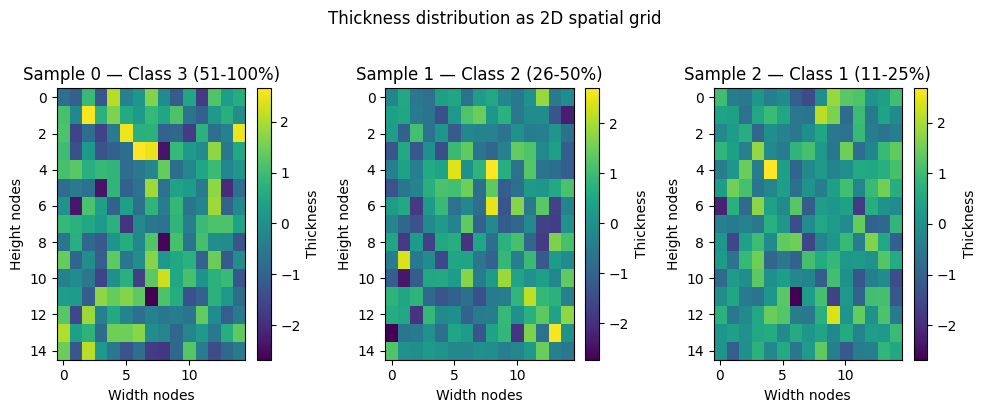

In [ ]:


GH = 15
GW = 15
TGT  = GH * GW

print(f"Reshaping 226 → ({GH}, {GW}) = {TGT} nodes")
print(f"Need to pad: {TGT - 226} zeros" if TGT > 226 else f"Need to trim: {226 - TGT}")

if TGT >= 226:
    padWidth = TGT - 226
    x2f = np.pad(xscl, ((0,0),(0,padWidth)), mode='constant', constant_values=0)
else:
    x2f = xscl[:, :TGT]

x2d = x2f.reshape(-1, 1, GH, GW).astype(np.float32)
print(f"\nX2d shape: {x2d.shape}")

plt.figure(figsize=(10, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(x2d[i, 0], cmap='viridis', aspect='auto')
    plt.colorbar(label='Thickness')
    plt.title(f'Sample {i} — Class {ycls[i]} ({cnm[ycls[i]]})')
    plt.xlabel('Width nodes'); plt.ylabel('Height nodes')
plt.suptitle('Thickness distribution as 2D spatial grid', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
class BData2(Dataset):
    def __init__(self, X, y, task='regression'):
        self.X    = torch.tensor(X, dtype=torch.float32)
        self.task = task
        if task == 'regression':
            self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        else:
            self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def mkdl2(x2d, y, task, valRatio=0.15, testRatio=0.15, batchSize=64):
    dataset = BData2(x2d, y, task=task)
    N       = len(dataset)
    nTest  = int(N * testRatio)
    nVal   = int(N * valRatio)
    nTrain = N - nVal - nTest

    trainDs, valDs, testDs = random_split(
        dataset, [nTrain, nVal, nTest],
        generator=torch.Generator().manual_seed(42)
    )
    trainLoader = DataLoader(trainDs, batchSize=batchSize, shuffle=True,  num_workers=0)
    valLoader   = DataLoader(valDs,   batchSize=batchSize, shuffle=False, num_workers=0)
    testLoader  = DataLoader(testDs,  batchSize=batchSize, shuffle=False, num_workers=0)

    print(f'[2D-{task}] Train={nTrain} | Val={nVal} | Test={nTest}')
    return trainLoader, valLoader, testLoader


trr2, valr2, ter2 = mkdl2(x2d, yreg, task='regression')
trainCls2d, valCls2d, testCls2d = mkdl2(x2d, ycls,      task='classification')
print("2D DataLoaders ready!")


[2D-regression] Train=3500 | Val=750 | Test=750
[2D-classification] Train=3500 | Val=750 | Test=750
✅ 2D DataLoaders ready!


---
## Step 4: CNN Architecture

```
Input: (batch, 1, 226)  ← 226 thickness values
   ↓  Conv1D (kernel=11) → captures long-range thickness interactions
   ↓  Conv1D (kernel=7)
   ↓  Conv1D (kernel=5)
   ↓  Conv1D (kernel=3)
   ↓  AdaptiveAvgPool → fixed size regardless of input length
   ↓  Flatten
   ↓  FC layers
   ↓
Output: 1 number (regression) OR 4 class scores (classification)
```


In [ ]:

class C2D(nn.Module):
    def __init__(self, outputSize=1, task='regression', dropout=0.3):
        super(C2D, self).__init__()
        self.task = task

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, outputSize),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


dummy2d = torch.randn(4, 1, GH, GW)
mR = C2D(outputSize=1, task='regression')
mC = C2D(outputSize=4, task='classification')
print('2D CNN Regression    output:', mR(dummy2d).shape)
print('2D CNN Classification output:', mC(dummy2d).shape)
print(f'Total params: {sum(p.numel() for p in mR.parameters()):,}')


2D CNN Regression    output: torch.Size([4, 1])
2D CNN Classification output: torch.Size([4, 4])
Total params: 435,681


---
## Step 5: Training Utilities


In [ ]:
def trainEpoch(model, loader, optimizer, criterion, device):
    model.train()
    totalLoss = 0.0
    for Xbatch, ybatch in loader:
        Xbatch, ybatch = Xbatch.to(device), ybatch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xbatch), ybatch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        totalLoss += loss.item() * len(Xbatch)
    return totalLoss / len(loader.dataset)


def evalEpoch(model, loader, criterion, device):
    model.eval()
    totalLoss = 0.0
    with torch.no_grad():
        for Xbatch, ybatch in loader:
            Xbatch, ybatch = Xbatch.to(device), ybatch.to(device)
            loss = criterion(model(Xbatch), ybatch)
            totalLoss += loss.item() * len(Xbatch)
    return totalLoss / len(loader.dataset)


def trainModel(model, trainLoader, valLoader, optimizer, criterion,
                nEpochs=150, patience=20, modelName='model',
                schedulerOverride=None):
    if schedulerOverride is not None:
        scheduler = schedulerOverride
        usePlateau = False
    else:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=7, factor=0.5, min_lr=1e-6
        )
        usePlateau = True

    bestValLoss    = float('inf')
    bestState       = None
    patienceCounter = 0
    history          = {'trainLoss': [], 'valLoss': [], 'lr': []}

    for epoch in range(1, nEpochs + 1):
        trainLoss = trainEpoch(model, trainLoader, optimizer, criterion, device)
        valLoss   = evalEpoch(model, valLoader,   criterion, device)
        currentLr = optimizer.param_groups[0]['lr']

        history['trainLoss'].append(trainLoss)
        history['valLoss'].append(valLoss)
        history['lr'].append(currentLr)

        if usePlateau:
            oldLr = currentLr
            scheduler.step(valLoss)
            newLr = optimizer.param_groups[0]['lr']
            if newLr != oldLr:
                print(f'  ⚡ LR: {oldLr:.6f} → {newLr:.6f}')
        else:
            scheduler.step()

        if valLoss < bestValLoss:
            bestValLoss    = valLoss
            bestState       = {k: v.clone() for k, v in model.state_dict().items()}
            patienceCounter = 0
        else:
            patienceCounter += 1

        if epoch % 10 == 0:
            print(f'[{modelName}] Epoch {epoch:3d}/{nEpochs} | '
                  f'Train: {trainLoss:.4f} | Val: {valLoss:.4f} | '
                  f'LR: {currentLr:.2e} | Patience: {patienceCounter}/{patience}')

        if patienceCounter >= patience:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    model.load_state_dict(bestState)
    print(f'\nDone. Best val loss: {bestValLoss:.4f}')
    return history


def plotHistory(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['trainLoss'], label='Train', color='steelblue')
    ax1.plot(history['valLoss'],   label='Val',   color='orange')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history['lr'], color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('LR')
    ax2.set_title('Learning Rate'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

print('Utilities ready!')


✅ Utilities ready!


---
## Approach 1: Regression CNN


🔴 APPROACH 1: 2D CNN Regression
[2D-CNN-Regression] Epoch  10/200 | Train: 0.2553 | Val: 0.1725 | LR: 2.77e-04 | Patience: 0/25
[2D-CNN-Regression] Epoch  20/200 | Train: 0.1196 | Val: 0.1069 | LR: 2.06e-04 | Patience: 2/25
[2D-CNN-Regression] Epoch  30/200 | Train: 0.0854 | Val: 0.0866 | LR: 1.13e-04 | Patience: 2/25
[2D-CNN-Regression] Epoch  40/200 | Train: 0.0740 | Val: 0.0834 | LR: 3.53e-05 | Patience: 6/25
[2D-CNN-Regression] Epoch  50/200 | Train: 0.0710 | Val: 0.0850 | LR: 1.30e-06 | Patience: 2/25
[2D-CNN-Regression] Epoch  60/200 | Train: 0.0713 | Val: 0.0973 | LR: 2.94e-04 | Patience: 1/25
[2D-CNN-Regression] Epoch  70/200 | Train: 0.0667 | Val: 0.0775 | LR: 2.74e-04 | Patience: 11/25
[2D-CNN-Regression] Epoch  80/200 | Train: 0.0562 | Val: 0.0780 | LR: 2.42e-04 | Patience: 1/25
[2D-CNN-Regression] Epoch  90/200 | Train: 0.0501 | Val: 0.0725 | LR: 2.01e-04 | Patience: 3/25
[2D-CNN-Regression] Epoch 100/200 | Train: 0.0439 | Val: 0.0718 | LR: 1.55e-04 | Patience: 9/25
[2D-CNN

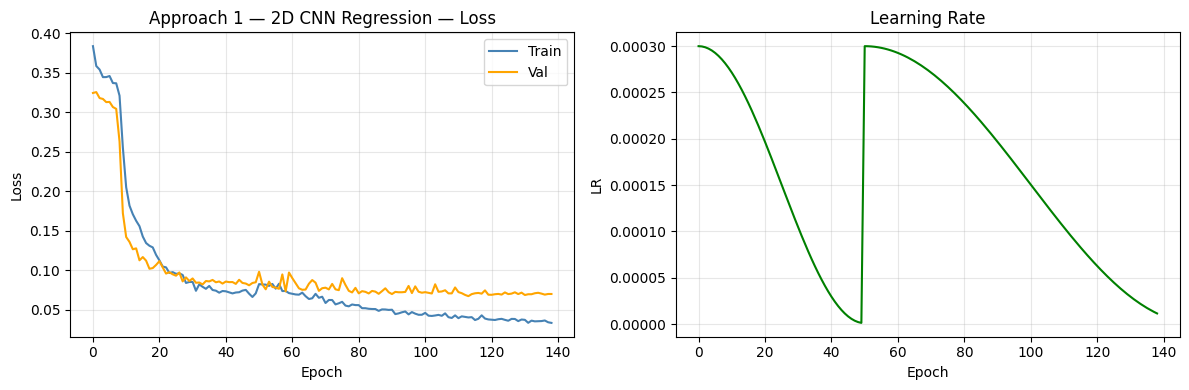

In [ ]:
print('APPROACH 1: 2D CNN Regression')
print('=' * 60)

mreg     = C2D(outputSize=1, task='regression', dropout=0.3).to(device)
optreg = optim.AdamW(mreg.parameters(), lr=3e-4, weight_decay=1e-3)
crreg = nn.HuberLoss(delta=1.0)
schreg = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optreg, T_0=50, T_mult=2, eta_min=1e-6
)

historyReg = trainModel(
    mreg, trr2, valr2,
    optreg, crreg,
    nEpochs=200, patience=25,
    modelName='2D-CNN-Regression',
    schedulerOverride=schreg
)
plotHistory(historyReg, 'Approach 1 — 2D CNN Regression')


📊 APPROACH 1 — Regression Results (Test Set)
   MAE  : 1023582.12
   RMSE : 1800562.86   ← large due to Pascal scale, ignore
   MAPE : 9.58%  ← % error, THIS matters
   R²   : 0.8363    ← THIS is the key metric

✅ Good!


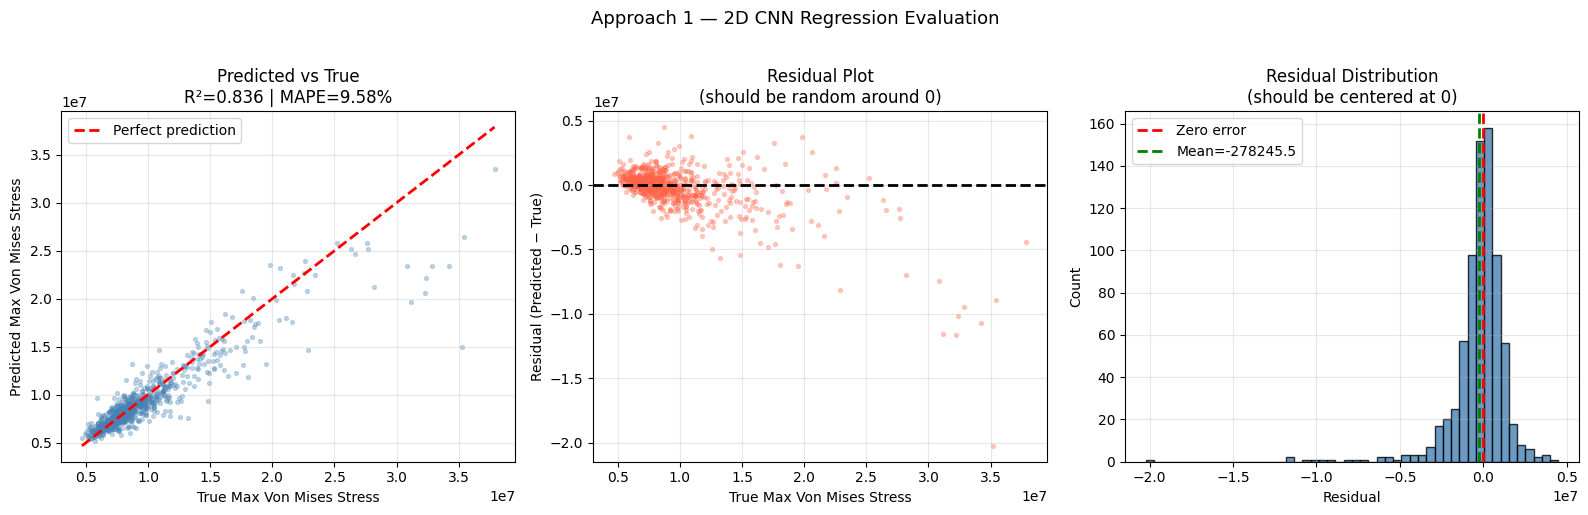


🔍 Top 10 Worst Predictions:
#               True       Predicted       Abs Error    % Error
------------------------------------------------------------
1        35229412.00     14993288.00     20236124.00      57.4%
2        32252692.00     20581612.00     11671080.00      36.2%
3        31166552.00     19632256.00     11534296.00      37.0%
4        34199224.00     23460552.00     10738672.00      31.4%
5        32344296.00     22166000.00     10178296.00      31.5%
6        32883488.00     23429336.00      9454152.00      28.8%
7        35418396.00     26463176.00      8955220.00      25.3%
8        22879220.00     14701076.00      8178144.00      35.7%
9        30853196.00     23432108.00      7421088.00      24.1%
10       28200116.00     21194032.00      7006084.00      24.8%


In [ ]:
mreg.eval()
prn, trn = [], []

with torch.no_grad():
    for Xbatch, ybatch in ter2:
        out = mreg(Xbatch.to(device)).cpu().numpy().flatten()
        prn.extend(out)
        trn.extend(ybatch.numpy().flatten())

pr = np.expm1(np.array(prn) * ystd + ymean)
tr = np.expm1(np.array(trn) * ystd + ymean)

mae  = mean_absolute_error(tr, pr)
rmse = np.sqrt(mean_squared_error(tr, pr))
r2   = r2_score(tr, pr)
mape = np.mean(np.abs((tr - pr) / (tr + 1e-8))) * 100

print("=" * 50)
print("APPROACH 1 — Regression Results (Test Set)")
print("=" * 50)
print(f"   MAE  : {mae:.2f}")
print(f"   RMSE : {rmse:.2f}   ← large due to Pascal scale, ignore")
print(f"   MAPE : {mape:.2f}%  ← % error, THIS matters")
print(f"   R²   : {r2:.4f}    ← THIS is the key metric")
print()
if   r2 > 0.90: print("Excellent!")
elif r2 > 0.80: print("Good!")
elif r2 > 0.70: print("Okay — try more epochs")
else:           print("Poor — check grid shape and data pairing")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(tr, pr, alpha=0.3, s=8, color='steelblue')
lims = [min(tr.min(), pr.min()),
        max(tr.max(), pr.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Max Von Mises Stress')
axes[0].set_ylabel('Predicted Max Von Mises Stress')
axes[0].set_title(f'Predicted vs True\nR²={r2:.3f} | MAPE={mape:.2f}%')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = pr - tr
axes[1].scatter(tr, residuals, alpha=0.3, s=8, color='tomato')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel('True Max Von Mises Stress')
axes[1].set_ylabel('Residual (Predicted − True)')
axes[1].set_title('Residual Plot\n(should be random around 0)')
axes[1].grid(alpha=0.3)

axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].axvline(0,               color='red',   lw=2, linestyle='--', label='Zero error')
axes[2].axvline(residuals.mean(), color='green', lw=2, linestyle='--',
                label=f'Mean={residuals.mean():.1f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution\n(should be centered at 0)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Approach 1 — 2D CNN Regression Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

errors     = np.abs(residuals)
top10Idx  = np.argsort(errors)[-10:][::-1]


In [ ]:

class OrdinalLoss(nn.Module):
    def __init__(self, numClasses=4, weight=None):
        super().__init__()
        self.numClasses = numClasses
        self.weight      = weight

        dist = torch.zeros(numClasses, numClasses)
        for i in range(numClasses):
            for j in range(numClasses):
                dist[i, j] = abs(i - j) + 1
        self.register_buffer('dist', dist)

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets,
            weight=self.weight,
            reduction='none'
        )
        probs      = torch.softmax(logits, dim=1)
        predClass = torch.argmax(probs, dim=1)
        ordWeight = self.dist[targets, predClass]
        return (ce * ordWeight).mean()


dummyLogits  = torch.randn(8, 4)
dummyTargets = torch.randint(0, 4, (8,))
lossFn = OrdinalLoss(numClasses=4)
print(f"OrdinalLoss test: {lossFn(dummyLogits, dummyTargets).item():.4f}")
print("OrdinalLoss ready!")


OrdinalLoss test: 5.5253
✅ OrdinalLoss ready!


---
## Approach 2: Classification CNN


🔵 APPROACH 2: 2D CNN Classification
Class weights:
  Class 0 (0-10%): weight=2.500  (500 samples)
  Class 1 (11-25%): weight=1.667  (750 samples)
  Class 2 (26-50%): weight=1.000  (1250 samples)
  Class 3 (51-100%): weight=0.500  (2500 samples)
[2D-CNN-Classification] Epoch  10/200 | Train: 1.3362 | Val: 1.3043 | LR: 2.77e-04 | Patience: 0/2

⏹️  Early stopping at epoch 18.

✅ Done. Best val loss: 1.0950


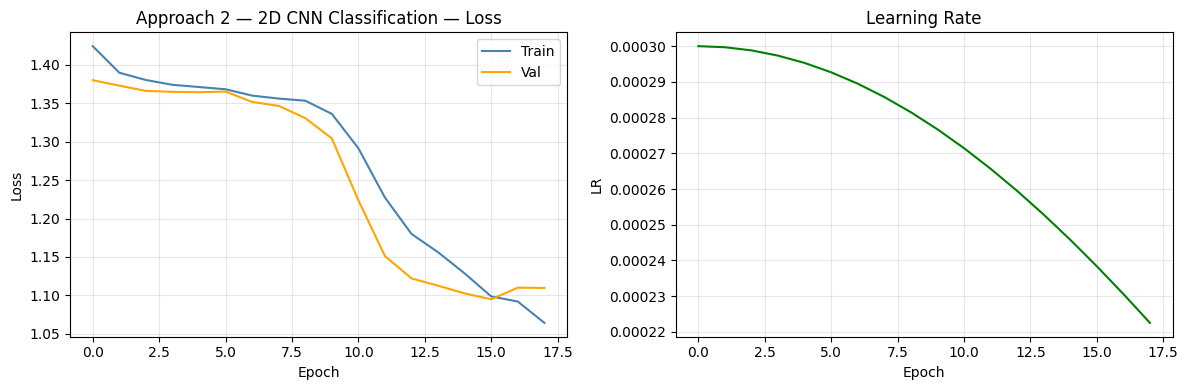

In [ ]:
print('APPROACH 2: 2D CNN Classification')
print('=' * 60)

uc, cc = np.uniq(ycls, return_counts=True)
cw = torch.tensor(
    [len(ycls) / (4 * c) for c in cc],
    dtype=torch.float32
).to(device)

print('Class weights:')
for i, (w, c) in enumerate(zip(cw.cpu(), cc)):
    print(f'  Class {i} ({cnm[i]}): weight={w:.3f}  ({c} samples)')

mcls     = C2D(outputSize=4, task='classification', dropout=0.3).to(device)
optcls = optim.AdamW(mcls.parameters(), lr=3e-4, weight_decay=1e-3)
crcls = nn.CrossEntropyLoss(
    weight=cw,
    label_smoothing=0.1
)
schcls = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optcls, T_0=50, T_mult=2, eta_min=1e-6
)

historyCls = trainModel(
    mcls, trainCls2d, valCls2d,
    optcls, crcls,
    nEpochs=200, patience=2,
    modelName='2D-CNN-Classification',
    schedulerOverride=schcls
)
plotHistory(historyCls, 'Approach 2 — 2D CNN Classification')


📊 APPROACH 2 — Classification Results (Test Set)
   Accuracy: 0.6253 (62.5%)

📋 Detailed Report:
              precision    recall  f1-score   support

       0-10%       0.52      0.84      0.64        77
      11-25%       0.33      0.43      0.37        96
      26-50%       0.49      0.49      0.49       201
     51-100%       0.88      0.70      0.78       376

    accuracy                           0.63       750
   macro avg       0.55      0.62      0.57       750
weighted avg       0.67      0.63      0.64       750

Predicted class distribution:
  Class 0 (0-10%): 126 predictions
  Class 1 (11-25%): 125 predictions
  Class 2 (26-50%): 199 predictions
  Class 3 (51-100%): 300 predictions


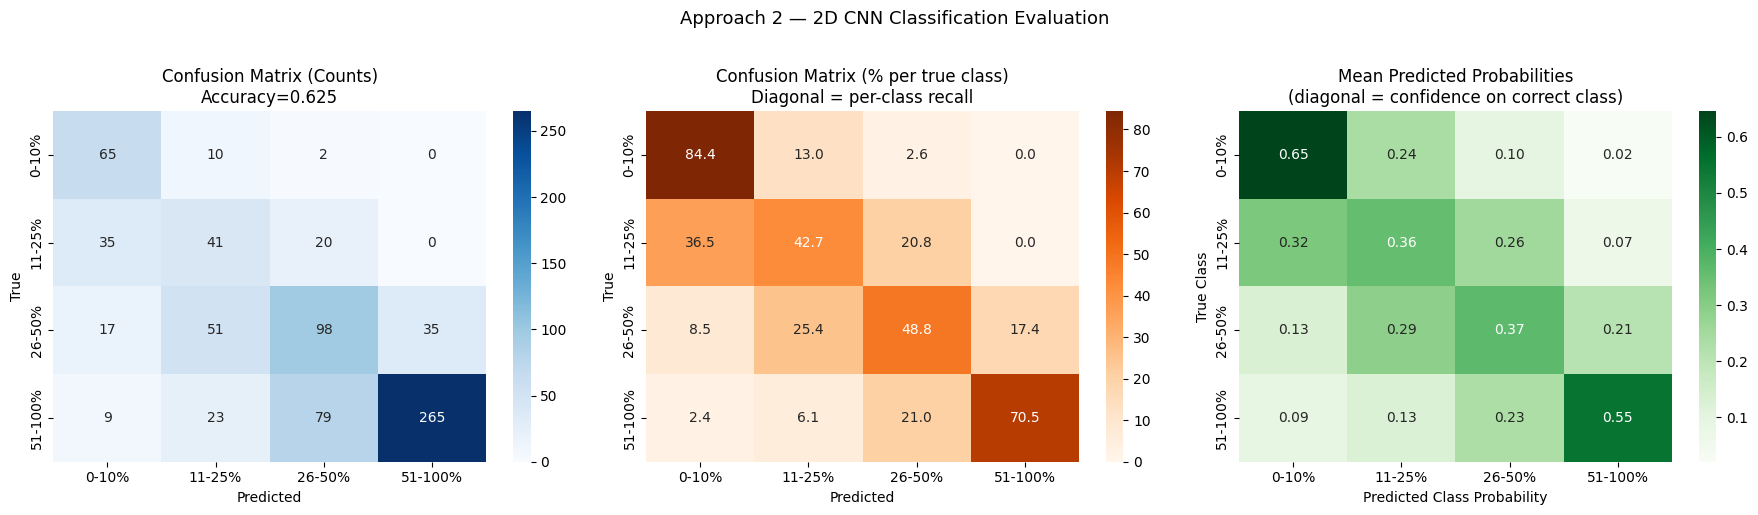

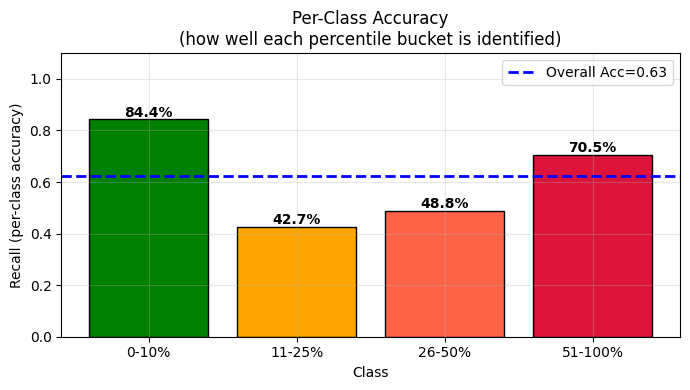

In [ ]:
mcls.eval()
pcls, tcls, pcls = [], [], []

with torch.no_grad():
    for Xbatch, ybatch in testCls2d:
        logits = mcls(Xbatch.to(device)).cpu()
        probs  = torch.softmax(logits, dim=1).numpy()
        pred   = torch.argmax(logits, dim=1).numpy()
        pcls.extend(pred)
        tcls.extend(ybatch.numpy())
        pcls.extend(probs)

pcls = np.array(pcls)
tcls = np.array(tcls)
pcls = np.array(pcls)

acc = accuracy_score(tcls, pcls)

print("=" * 50)
print("APPROACH 2 — Classification Results (Test Set)")
print("=" * 50)
print(f"   Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print()
print("Detailed Report:")
print(classification_report(tcls, pcls, target_names=cnm))

print("Predicted class distribution:")
for c in range(4):
    count = (pcls == c).sum()
    print(f"  Class {c} ({cnm[c]}): {count} predictions")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(tcls, pcls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cnm, yticklabels=cnm)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix (Counts)\nAccuracy={acc:.3f}')

cmNorm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cmNorm, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=cnm, yticklabels=cnm)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (% per true class)\nDiagonal = per-class recall')

meanProbs = np.zeros((4, 4))
for trueC in range(4):
    mask = tcls == trueC
    if mask.sum() > 0:
        meanProbs[trueC] = pcls[mask].mean(axis=0)

sns.heatmap(meanProbs, annot=True, fmt='.2f', cmap='Greens', ax=axes[2],
            xticklabels=cnm, yticklabels=cnm)
axes[2].set_xlabel('Predicted Class Probability')
axes[2].set_ylabel('True Class')
axes[2].set_title('Mean Predicted Probabilities\n(diagonal = confidence on correct class)')

plt.suptitle('Approach 2 — 2D CNN Classification Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

perClassAcc = cmNorm.diagonal() / 100
plt.figure(figsize=(7, 4))
bars = plt.bar(cnm, perClassAcc,
               color=['green','orange','tomato','crimson'], edgecolor='black')
plt.axhline(acc, color='blue', linestyle='--', lw=2, label=f'Overall Acc={acc:.2f}')
for bar, val in zip(bars, perClassAcc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val*100:.1f}%', ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.xlabel('Class'); plt.ylabel('Recall (per-class accuracy)')
plt.title('Per-Class Accuracy\n(how well each percentile bucket is identified)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 6: Compare Approach 1 vs Approach 2


🏆  COMPARISON SUMMARY
Approach 1 (Regression):
  R²   = 0.8363
  MAPE = 9.58%
  When converted to classes → Accuracy = 0.7093

Approach 2 (Classification):
  Accuracy = 0.6253


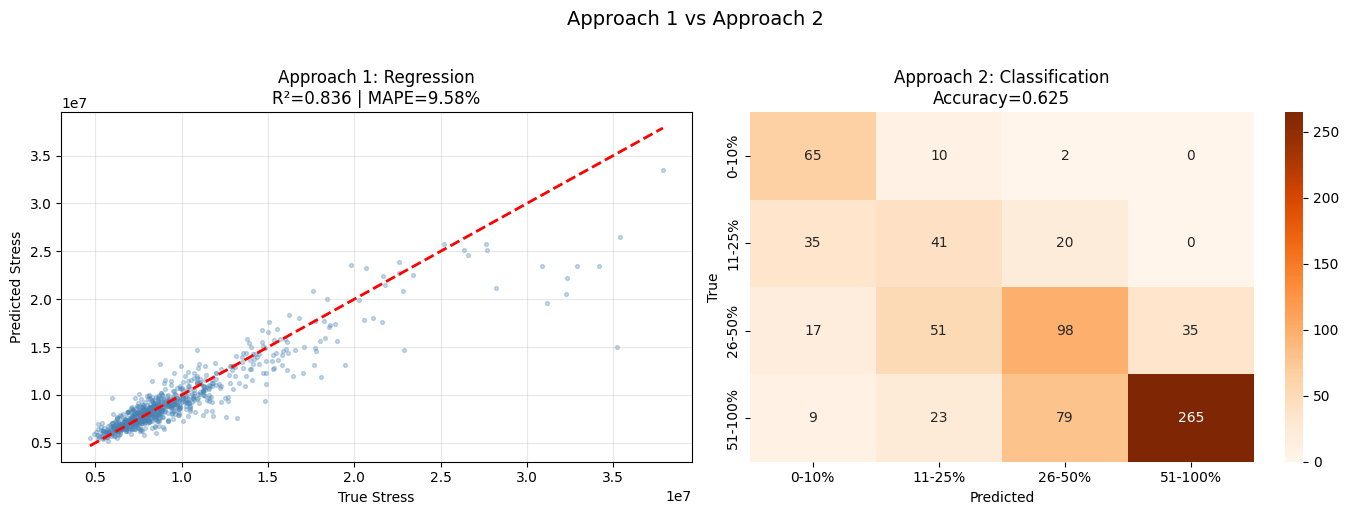

In [ ]:
def stressToClass(stressVals, p10, p25, p50):
    return np.array([asg(s, p10, p25, p50) for s in stressVals])

predsRegAsCls = stressToClass(pr, p10, p25, p50)
truesAsCls     = stressToClass(tr, p10, p25, p50)

accRegConverted = accuracy_score(truesAsCls, predsRegAsCls)
accClsDirect    = accuracy_score(tcls,    pcls)

print('=' * 60)
print('COMPARISON SUMMARY')
print('=' * 60)
print(f'Approach 1 (Regression):')
print(f'  R²   = {r2:.4f}')
print(f'  MAPE = {mape:.2f}%')
print(f'  When converted to classes → Accuracy = {accRegConverted:.4f}')
print()
print(f'Approach 2 (Classification):')
print(f'  Accuracy = {accClsDirect:.4f}')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tr, pr, alpha=0.3, s=8, color='steelblue')
lims = [min(tr.min(), pr.min()),
        max(tr.max(), pr.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('True Stress'); axes[0].set_ylabel('Predicted Stress')
axes[0].set_title(f'Approach 1: Regression\nR²={r2:.3f} | MAPE={mape:.2f}%')
axes[0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=cnm, yticklabels=cnm)
axes[1].set_title(f'Approach 2: Classification\nAccuracy={accClsDirect:.3f}')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Approach 1 vs Approach 2', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## Step 7: Data Efficiency Experiment


In [ ]:
from sklearn.model_selection import train_test_split


def quickExperiment(x2d, yreg, ycls, nSamples, epochs=40):
    idx   = np.random.choice(len(x2d), nSamples, replace=False)
    Xs   = x2d[idx]
    yrS  = yreg[idx]
    ycS  = ycls[idx]

    Xtr, Xte, yrTr, yrTe, ycTr, ycTe = train_test_split(
        Xs, yrS, ycS, test_size=0.2, random_state=42
    )

    uc, cc = np.uniq(ycTr, return_counts=True)
    wts = torch.zeros(4, dtype=torch.float32)
    for u, c in zip(uc, cc):
        wts[u] = len(ycTr) / (4 * c)
    wts = wts.to(device)

    def makeLoader2d(X, y, task, bs=32, shuffle=False):
        ds = BData2(X, y.astype(np.float32) if task == 'regression' else y, task)
        return DataLoader(ds, batchSize=bs, shuffle=shuffle, num_workers=0)

    rlTr = makeLoader2d(Xtr, yrTr, 'regression', bs=32, shuffle=True)
    rlTe = makeLoader2d(Xte, yrTe, 'regression', bs=32, shuffle=False)
    clTr = makeLoader2d(Xtr, ycTr, 'classification', bs=32, shuffle=True)
    clTe = makeLoader2d(Xte, ycTe, 'classification', bs=32, shuffle=False)

    mr    = C2D(outputSize=1, task='regression').to(device)
    optR = optim.AdamW(mr.parameters(), lr=3e-4, weight_decay=1e-3)
    critR = nn.HuberLoss(delta=1.0)
    for _ in range(epochs):
        trainEpoch(mr, rlTr, optR, critR, device)

    mr.eval()
    pr, trExp = [], []
    with torch.no_grad():
        for xb, yb in rlTe:
            pr.extend(mr(xb.to(device)).cpu().numpy().flatten())
            trExp.extend(yb.numpy().flatten())
    r2 = r2_score(trExp, pr)

    mc    = C2D(outputSize=4, task='classification').to(device)
    optC = optim.AdamW(mc.parameters(), lr=3e-4, weight_decay=1e-3)
    critC = nn.CrossEntropyLoss(weight=wts)
    for _ in range(epochs):
        trainEpoch(mc, clTr, optC, critC, device)

    mc.eval()
    pc, tc = [], []
    with torch.no_grad():
        for xb, yb in clTe:
            pc.extend(torch.argmax(mc(xb.to(device)), dim=1).cpu().numpy())
            tc.extend(yb.numpy())
    acc = accuracy_score(tc, pc)

    return r2, acc


sampleSizes = [100, 250, 500, 1000, 2000, 4000]
r2Scores, accScores = [], []

print('🔬 Running data efficiency experiment...')
for n in sampleSizes:
    r2, acc = quickExperiment(x2d, yreg, ycls, nSamples=n, epochs=40)
    r2Scores.append(max(r2, 0))
    accScores.append(acc)
    print(f'  n={n:5d}: Regression R²={r2:.3f}  |  Classification Acc={acc:.3f}')


🔬 Running data efficiency experiment...
  n=  100: Regression R²=-0.544  |  Classification Acc=0.400
  n=  250: Regression R²=-0.257  |  Classification Acc=0.240
  n=  500: Regression R²=0.405  |  Classification Acc=0.300
  n= 1000: Regression R²=0.594  |  Classification Acc=0.480


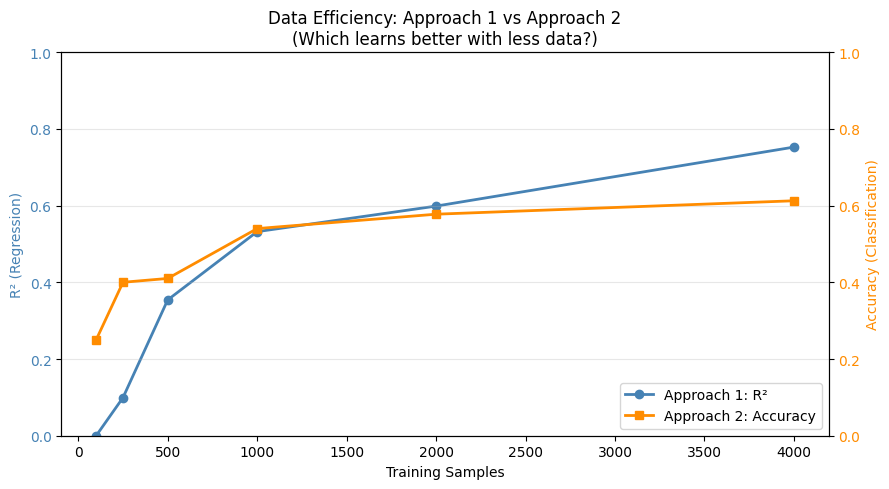

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

c1, c2 = 'steelblue', 'darkorange'
ax1.plot(sampleSizes, r2Scores, 'o-', color=c1, lw=2, label='Approach 1: R²')
ax1.set_xlabel('Training Samples'); ax1.set_ylabel('R² (Regression)', color=c1)
ax1.tick_params(axis='y', labelcolor=c1); ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(sampleSizes, accScores, 's-', color=c2, lw=2, label='Approach 2: Accuracy')
ax2.set_ylabel('Accuracy (Classification)', color=c2)
ax2.tick_params(axis='y', labelcolor=c2); ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Data Efficiency: Approach 1 vs Approach 2\n(Which learns better with less data?)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
